# Paper Validation Example

This notebook sets up a small dummy system for validating optimex results against hand calculations. It follows the structure of `basic_example.ipynb`, but keeps the foreground model deliberately small.

## 1. Database Setup

We create a standalone Brightway project with:

- one biosphere flow: CO2
- three background databases for 2020, 2035, and 2050
- one foreground product with two alternative production routes

The foreground routes include the optimex-specific process information: `operation_time_limits`, `temporal_distribution`, and `operation=True` on operation-phase exchanges.

In [1]:
from datetime import datetime

import numpy as np
import bw2data as bd
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution

bd.projects.set_current("optimex_paper_validation_example")

c:\Users\lucal\Brightway\optimex\.venv\Lib\site-packages\bw2calc\__init__.py:57: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")
c:\Users\lucal\Brightway\optimex\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
for db_name in ["biosphere3", "db_2020", "db_2035", "db_2050", "foreground"]:
    if db_name in bd.databases:
        del bd.databases[db_name]

### Biosphere

In [3]:
biosphere_data = {
    ("biosphere3", "CO2"): {
        "type": bd.labels.biosphere_node_default,
        "name": "carbon dioxide",
        "unit": "kg",
    },
}

bd.Database("biosphere3").write(biosphere_data)

100%|██████████| 1/1 [00:00<?, ?it/s]


15:33:29+0200 [info     ] Vacuuming database            


### Characterization Method

In [4]:
bd.Method(("GWP", "paper_validation")).write(
    [
        (("biosphere3", "CO2"), 1.0),
    ]
)

### Background Databases

The background databases contain the direct inputs used by the foreground routes. `dirty_energy` becomes cleaner over time, while `clean_energy` stays constant. `market_price` provides the cost data used later by the cost objective.

In [5]:
def make_background_data(db_name, dirty_co2, clean_co2):
    return {
        (db_name, "dirty_energy"): {
            "name": "dirty energy",
            "location": "GLO",
            "unit": "unit",
            "type": bd.labels.chimaera_node_default,
            "reference product": "dirty energy",
            "market_price": 3.0,
            "exchanges": [
                {
                    "amount": 1,
                    "type": bd.labels.production_edge_default,
                    "input": (db_name, "dirty_energy"),
                },
                {
                    "amount": dirty_co2,
                    "type": bd.labels.biosphere_edge_default,
                    "input": ("biosphere3", "CO2"),
                },
            ],
        },
        (db_name, "clean_energy"): {
            "name": "clean energy",
            "location": "GLO",
            "unit": "unit",
            "type": bd.labels.chimaera_node_default,
            "reference product": "clean energy",
            "market_price": 9.0,
            "exchanges": [
                {
                    "amount": 1,
                    "type": bd.labels.production_edge_default,
                    "input": (db_name, "clean_energy"),
                },
                {
                    "amount": clean_co2,
                    "type": bd.labels.biosphere_edge_default,
                    "input": ("biosphere3", "CO2"),
                },
            ],
        },
        (db_name, "plant_material"): {
            "name": "plant material",
            "location": "GLO",
            "unit": "unit",
            "type": bd.labels.chimaera_node_default,
            "reference product": "plant material",
            "market_price": 1.0,
            "exchanges": [
                {
                    "amount": 1,
                    "type": bd.labels.production_edge_default,
                    "input": (db_name, "plant_material"),
                },
                {
                    "amount": 1.0,
                    "type": bd.labels.biosphere_edge_default,
                    "input": ("biosphere3", "CO2"),
                },
            ],
        },
    }

In [6]:
background_specs = {
    "db_2020": {"year": 2020, "dirty_co2": 12.0, "clean_co2": 2.0},
    "db_2035": {"year": 2035, "dirty_co2": 8.0, "clean_co2": 2.0},
    "db_2050": {"year": 2050, "dirty_co2": 4.0, "clean_co2": 2.0},
}

for db_name, spec in background_specs.items():
    db = bd.Database(db_name)
    db.write(
        make_background_data(
            db_name=db_name,
            dirty_co2=spec["dirty_co2"],
            clean_co2=spec["clean_co2"],
        )
    )
    db.metadata["representative_time"] = datetime(spec["year"], 1, 1).isoformat()
    db.register()

100%|██████████| 3/3 [00:00<00:00, 2075.36it/s]


15:33:33+0200 [info     ] Vacuuming database            


100%|██████████| 3/3 [00:00<?, ?it/s]


15:33:34+0200 [info     ] Vacuuming database            


100%|██████████| 3/3 [00:00<?, ?it/s]


15:33:34+0200 [info     ] Vacuuming database            


### Foreground Database

The foreground has one product and two routes. Construction input occurs at process time `tau=0` and is not marked as operational. Product output and energy input occur during the operation phase and are marked with `operation=True`.

In [7]:
foreground = bd.Database("foreground")
foreground.register()

In [8]:
construction_td = TemporalDistribution(
    date=np.array([0], dtype="timedelta64[Y]"),
    amount=np.array([1.0]),
)

cheap_operation_td = easy_timedelta_distribution(
    start=0,
    end=5,
    steps=6,
    resolution="Y",
    kind="uniform",
)

clean_operation_td = easy_timedelta_distribution(
    start=0,
    end=15,
    steps=16,
    resolution="Y",
    kind="uniform",
)

In [9]:
foreground_data = {
    ("foreground", "product"): {
        "name": "Product",
        "unit": "unit",
        "type": bd.labels.product_node_default,
    },
    ("foreground", "cheap_dirty"): {
        "name": "Cheap dirty route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, 5),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product"),
                "temporal_distribution": cheap_operation_td,
                "operation": True,
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2020", "plant_material"),
                "temporal_distribution": construction_td,
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2020", "dirty_energy"),
                "temporal_distribution": cheap_operation_td,
                "operation": True,
            },
        ],
    },
    ("foreground", "expensive_clean"): {
        "name": "Expensive clean route",
        "location": "GLO",
        "type": bd.labels.process_node_default,
        "operation_time_limits": (0, 15),
        "exchanges": [
            {
                "amount": 1.0,
                "type": bd.labels.production_edge_default,
                "input": ("foreground", "product"),
                "temporal_distribution": clean_operation_td,
                "operation": True,
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2020", "plant_material"),
                "temporal_distribution": construction_td,
            },
            {
                "amount": 1.0,
                "type": bd.labels.consumption_edge_default,
                "input": ("db_2020", "clean_energy"),
                "temporal_distribution": clean_operation_td,
                "operation": True,
            },
        ],
    },
}

fg = bd.Database("foreground")
fg.write(foreground_data)
fg.register()

100%|██████████| 3/3 [00:00<?, ?it/s]


15:33:43+0200 [info     ] Vacuuming database            


### Demand

In [10]:
years = range(2020, 2051)

td_demand = TemporalDistribution(
    date=np.array(
        [datetime(year, 1, 1).isoformat() for year in years],
        dtype="datetime64[s]",
    ),
    amount=np.full(len(years), 10.0),
)

functional_demand = {
    bd.get_node(database="foreground", name="Product"): td_demand
}

## 2. LCA Processing

Configure the LCA processing step. This extracts the time-explicit foreground tensors, background inventories, background mapping, characterization tensor, and cost inputs from the dummy Brightway databases.

In [11]:
from optimex import lca_processor

lca_config = lca_processor.LCAConfig(
    demand=functional_demand,
    temporal={
        "start_date": datetime(2020, 1, 1),
        "temporal_resolution": "year",
        "time_horizon": 40,
    },
    characterization_methods=[
        {
            "category_name": "climate_change",
            "brightway_method": ("GWP", "paper_validation"),
        },
    ],
)

lca_data_processor = lca_processor.LCADataProcessor(lca_config)

2026-06-21 15:34:01.670 | INFO     | optimex.lca_processor:_parse_demand:460 - Identified demand in system time range of %s for products %s
2026-06-21 15:34:01.686 | INFO     | optimex.lca_processor:_construct_foreground_tensors:699 - Constructed foreground tensors.
2026-06-21 15:34:01.691 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Technosphere (external) shape: (2 processes, 3 flows, 16 years) with 24 total entries.
2026-06-21 15:34:01.694 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Internal demand shape: (0 processes, 0 flows, 0 years) with 0 total entries.
2026-06-21 15:34:01.698 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Biosphere shape: (0 processes, 0 flows, 0 years) with 0 total entries.
2026-06-21 15:34:01.701 | INFO     | optimex.lca_processor:log_tensor_dimensions:694 - Production shape: (2 processes, 1 flows, 16 years) with 22 total entries.
2026-06-21 15:34:01.715 | INFO     | optimex.lca_processor:_calculate_invent

### Convert to Optimization Inputs

In [12]:
from optimex import converter

manager = converter.ModelInputManager()
optimization_model_inputs = manager.parse_from_lca_processor(lca_data_processor)

Inspect the cost inputs created from the `market_price` attributes. `plant_material` is installation-related, while `dirty_energy` and `clean_energy` are operation-related.

In [13]:
optimization_model_inputs.intermediate_costs_cap

{('plant_material', 2020): 1.0,
 ('plant_material', 2021): 1.0,
 ('plant_material', 2022): 1.0,
 ('plant_material', 2023): 1.0,
 ('plant_material', 2024): 1.0,
 ('plant_material', 2025): 1.0,
 ('plant_material', 2026): 1.0,
 ('plant_material', 2027): 1.0,
 ('plant_material', 2028): 1.0,
 ('plant_material', 2029): 1.0,
 ('plant_material', 2030): 1.0,
 ('plant_material', 2031): 1.0,
 ('plant_material', 2032): 1.0,
 ('plant_material', 2033): 1.0,
 ('plant_material', 2034): 1.0,
 ('plant_material', 2035): 1.0,
 ('plant_material', 2036): 1.0,
 ('plant_material', 2037): 1.0,
 ('plant_material', 2038): 1.0,
 ('plant_material', 2039): 1.0,
 ('plant_material', 2040): 1.0,
 ('plant_material', 2041): 1.0,
 ('plant_material', 2042): 1.0,
 ('plant_material', 2043): 1.0,
 ('plant_material', 2044): 1.0,
 ('plant_material', 2045): 1.0,
 ('plant_material', 2046): 1.0,
 ('plant_material', 2047): 1.0,
 ('plant_material', 2048): 1.0,
 ('plant_material', 2049): 1.0,
 ('plant_material', 2050): 1.0}

In [14]:
optimization_model_inputs.intermediate_costs_op

{('clean_energy', 2020): 9.0,
 ('clean_energy', 2021): 9.0,
 ('clean_energy', 2022): 9.0,
 ('clean_energy', 2023): 9.0,
 ('clean_energy', 2024): 9.0,
 ('clean_energy', 2025): 9.0,
 ('clean_energy', 2026): 9.0,
 ('clean_energy', 2027): 9.0,
 ('clean_energy', 2028): 9.0,
 ('clean_energy', 2029): 9.0,
 ('clean_energy', 2030): 9.0,
 ('clean_energy', 2031): 9.0,
 ('clean_energy', 2032): 9.0,
 ('clean_energy', 2033): 9.0,
 ('clean_energy', 2034): 9.0,
 ('clean_energy', 2035): 9.0,
 ('clean_energy', 2036): 9.0,
 ('clean_energy', 2037): 9.0,
 ('clean_energy', 2038): 9.0,
 ('clean_energy', 2039): 9.0,
 ('clean_energy', 2040): 9.0,
 ('clean_energy', 2041): 9.0,
 ('clean_energy', 2042): 9.0,
 ('clean_energy', 2043): 9.0,
 ('clean_energy', 2044): 9.0,
 ('clean_energy', 2045): 9.0,
 ('clean_energy', 2046): 9.0,
 ('clean_energy', 2047): 9.0,
 ('clean_energy', 2048): 9.0,
 ('clean_energy', 2049): 9.0,
 ('clean_energy', 2050): 9.0,
 ('dirty_energy', 2020): 3.0,
 ('dirty_energy', 2021): 3.0,
 ('dirty_e

## 3. Optimization

We solve three scenarios:

1. cost-only optimization
2. environmental-only optimization
3. cost optimization under a cumulative climate constraint

In [15]:
import pandas as pd
import pyomo.environ as pyo

from optimex import optimizer

solver_name = "highs"


def total_operation(model, process, year):
    return sum(
        pyo.value(model.var_operation[p, vintage, time])
        for (p, vintage, time) in model.ACTIVE_VINTAGE_TIME
        if p == process and time == year
    )


def real_total_impact(model, category="climate_change"):
    return (
        pyo.value(model.total_impact[category])
        * model.scales["foreground"]
        * model.scales["characterization"][category]
    )


def nonzero_installations(model, threshold=1e-6):
    rows = []
    for process in model.PROCESS:
        for year in model.SYSTEM_TIME:
            value = pyo.value(model.var_installation[process, year])
            if abs(value) > threshold:
                rows.append({"process": process, "year": year, "installation": value})
    return pd.DataFrame(rows)


def operation_table(model):
    rows = []
    for year in model.SYSTEM_TIME:
        row = {"year": year}
        for process in model.PROCESS:
            row[process] = total_operation(model, process, year)
        rows.append(row)
    return pd.DataFrame(rows)


def scenario_summary(model, objective_value):
    return pd.DataFrame(
        [
            {
                "objective_value": objective_value,
                "total_cost": pyo.value(model.total_cost),
                "total_climate_change": real_total_impact(model),
            }
        ]
    )

### Scenario 1: Cost Only Optimization

In [16]:
cost_model = optimizer.create_model(
    optimization_model_inputs,
    name="paper_validation_cost_only",
    objective_category="climate_change",
    objective="cost",
)

cost_model, cost_objective, cost_results = optimizer.solve_model(
    cost_model,
    solver_name=solver_name,
    tee=False,
)

2026-06-21 15:34:55.213 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-21 15:34:55.217 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-21 15:34:55.221 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-21 15:34:55.496 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-21 15:34:55.504 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 990


In [17]:
scenario_summary(cost_model, cost_objective)

,objective_value,total_cost,total_climate_change
0,990.0,990.0,2540.0


In [18]:
operation_table(cost_model)

,year,expensive_clean,cheap_dirty
0,2020,0.0,10.0
1,2021,0.0,10.0
2,2022,0.0,10.0
3,2023,0.0,10.0
4,2024,0.0,10.0
5,2025,0.0,10.0
6,2026,0.0,10.0
7,2027,0.0,10.0
8,2028,0.0,10.0
9,2029,0.0,10.0


In [19]:
nonzero_installations(cost_model)

,process,year,installation
0,cheap_dirty,2020,10.0
1,cheap_dirty,2026,10.0
2,cheap_dirty,2030,10.0
3,cheap_dirty,2036,10.0
4,cheap_dirty,2042,10.0
5,cheap_dirty,2045,10.0


### Scenario 2: Environmental Only Optimization

In [20]:
environmental_model = optimizer.create_model(
    optimization_model_inputs,
    name="paper_validation_environmental_only",
    objective_category="climate_change",
    objective="environmental",
)

environmental_model, environmental_objective, environmental_results = optimizer.solve_model(
    environmental_model,
    solver_name=solver_name,
    tee=False,
)

2026-06-21 15:35:33.656 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-21 15:35:33.660 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-21 15:35:33.665 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-21 15:35:33.835 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-21 15:35:33.847 | INFO     | optimex.optimizer:solve_model:1250 - Objective (scaled): 640
2026-06-21 15:35:33.847 | INFO     | optimex.optimizer:solve_model:1251 - Objective (real):   640


In [21]:
scenario_summary(environmental_model, environmental_objective)

,objective_value,total_cost,total_climate_change
0,640.0,2810.0,640.0


In [22]:
operation_table(environmental_model)

,year,expensive_clean,cheap_dirty
0,2020,10.0,0.0
1,2021,10.0,0.0
2,2022,10.0,0.0
3,2023,10.0,0.0
4,2024,10.0,0.0
5,2025,10.0,0.0
6,2026,10.0,0.0
7,2027,10.0,0.0
8,2028,10.0,0.0
9,2029,10.0,0.0


In [23]:
nonzero_installations(environmental_model)

,process,year,installation
0,expensive_clean,2020,10.0
1,expensive_clean,2035,10.0


### Scenario 3: Cost Optimization Under Environmental Constraint

The cumulative climate budget is intentionally set between the cost-only and environmental-only solutions, so the model must use a mix of both routes.

In [24]:
environmental_budget = 1590.0

constrained_inputs = optimization_model_inputs.model_copy(deep=True)
constrained_inputs.cumulative_category_impact_limits = {
    "climate_change": environmental_budget,
}

constrained_cost_model = optimizer.create_model(
    constrained_inputs,
    name="paper_validation_cost_with_climate_budget",
    objective_category="climate_change",
    objective="cost",
)

constrained_cost_model, constrained_cost_objective, constrained_cost_results = optimizer.solve_model(
    constrained_cost_model,
    solver_name=solver_name,
    tee=False,
)

2026-06-21 15:37:21.098 | INFO     | optimex.optimizer:create_model:126 - Creating sets
2026-06-21 15:37:21.102 | INFO     | optimex.optimizer:create_model:168 - Creating parameters
2026-06-21 15:37:21.110 | INFO     | optimex.optimizer:create_model:498 - Creating variables
2026-06-21 15:37:21.310 | INFO     | optimex.optimizer:solve_model:1232 - Solver [highs] termination: optimal
2026-06-21 15:37:21.318 | INFO     | optimex.optimizer:solve_model:1240 - Objective (cost): 1624.97


In [25]:
scenario_summary(constrained_cost_model, constrained_cost_objective)

,objective_value,total_cost,total_climate_change
0,1624.966443,1624.966443,1590.0


In [26]:
operation_table(constrained_cost_model)

,year,expensive_clean,cheap_dirty
0,2020,10.000000,0.000000
1,2021,10.000000,0.000000
2,2022,10.000000,0.000000
3,2023,10.000000,0.000000
4,2024,10.000000,0.000000
5,2025,10.000000,0.000000
6,2026,10.000000,0.000000
7,2027,10.000000,0.000000
8,2028,10.000000,0.000000
9,2029,4.563758,5.436242


In [27]:
nonzero_installations(constrained_cost_model)

,process,year,installation
0,expensive_clean,2020,10.000000
1,cheap_dirty,2028,5.436242
2,cheap_dirty,2033,10.000000
3,cheap_dirty,2039,10.000000
4,cheap_dirty,2045,10.000000


## 4. Post-processing

Use the constrained scenario for the same style of plots shown in the basic example.

In [28]:
from optimex import postprocessing

pp = postprocessing.PostProcessor(
    constrained_cost_model,
    plot_config={"figsize": (8, 4)},
)

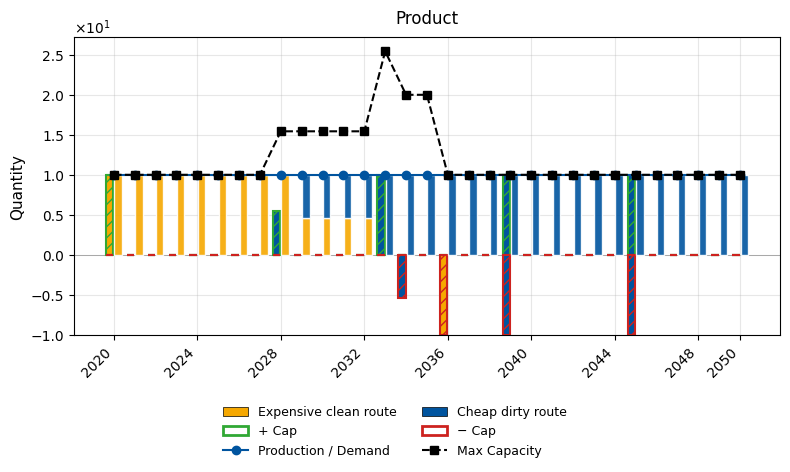

In [29]:
pp.plot_capacity_balance(detailed=True)

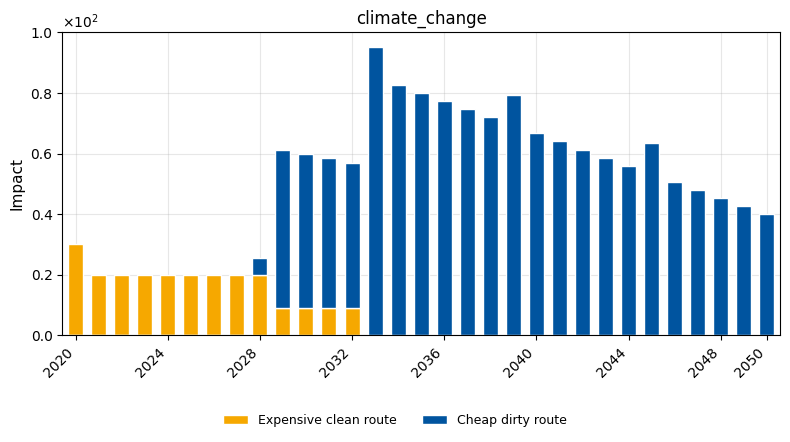

In [30]:
pp.plot_impacts()